In [ ]:
# in case of working in Colab or if there is no ultralytics on local machine
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.8 MB/s eta 0:00:00


In [ ]:
# here prepared code for working using colab in separate cell example for local computer but it can demand using mac or machine with gpu

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import sys
from ultralytics import YOLO

# connecting to folder on google drive - in folder video for analysis anf weights for fine-tuned YOLO
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Fish/'

# name of file for processing
video_path = path + 'fish_detection_1.mp4'

# name of output file 
output_path = video_path[:-4] + '_output.mp4'

# fine-tuned model
model = YOLO("/content/drive/MyDrive/Fish/runs/detect/train/weights/best.pt")

print()
print(video_path)
print(output_path)

In [ ]:
# same operations in case of working localy

'''
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

from ultralytics import YOLO

path = sys.path[0]
print(path)

# name of file for processing
video_path = path + '/fish_detection_1.mp4'

# name of output file
output_path = video_path[:-4] + '_output.mp4'

# fine-tuned model
model = YOLO("runs/detect/train/weights/best.pt")

print()
print(video_path)
print(output_path)
'''

/Users/vladkozlovskiy/Desktop/SEAS/Fish_project

/Users/vladkozlovskiy/Desktop/SEAS/Fish_project/fish_detection_1.mp4
/Users/vladkozlovskiy/Desktop/SEAS/Fish_project/fish_detection_1_output.mp4


# Part for making processed video with bounds: '01_before_proc_output.mp4', analytics, saving of metrics and images


0: 384x640 3 fishs, 58.1ms
Speed: 3.6ms preprocess, 58.1ms inference, 8.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 41.5ms
Speed: 1.7ms preprocess, 41.5ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 42.9ms
Speed: 1.1ms preprocess, 42.9ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 43.0ms
Speed: 1.9ms preprocess, 43.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 39.3ms
Speed: 1.4ms preprocess, 39.3ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 40.9ms
Speed: 1.4ms preprocess, 40.9ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 37.3ms
Speed: 1.1ms preprocess, 37.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 fishs, 44.7ms
Speed: 1.3ms preprocess, 44.7ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


/Users/vladkozlovskiy/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/vladkozlovskiy/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


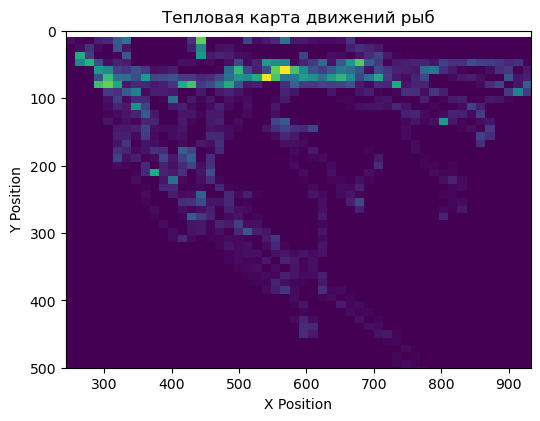

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


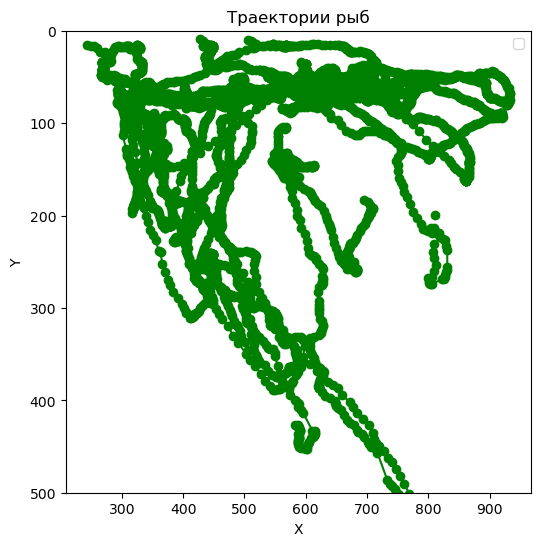

In [ ]:
last_positions = {}   # {id: (x, y)}
trajectories = {}      # {id: [(x, y), (x, y), ...]}

#FEEDING_FRAME = 1000

frame_count = 0

# video input / output
cap = cv2.VideoCapture(video_path)
out = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    cap.get(cv2.CAP_PROP_FPS),
    (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

    # run YOLO tracking (with ByteTrack)
    results = model.track(frame, tracker="bytetrack.yaml", persist=True, classes=[0])

    # if any tracks exist
    if results[0].boxes.id is not None:  
        boxes = results[0].boxes.xyxy.cpu().numpy()  # [x1,y1,x2,y2]
        ids = results[0].boxes.id.int().cpu().numpy()  # Track IDs

        for box, track_id in zip(boxes, ids):
            x1, y1, x2, y2 = map(int, box)
            cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)

            # compute speed if previous position exists
            speed = 0
            if track_id in last_positions:
                px, py = last_positions[track_id]
                speed = np.sqrt((cx - px) ** 2 + (cy - py) ** 2)

            # save current position
            last_positions[track_id] = (cx, cy)

            # define color by speed
            if speed < 3:
                text_sign = 'chill'
                color = (0, 255, 0)   # red = slow

           # elif speed < 5:
           #     text_sign = 'works'
           #     color = (0, 255, 255) # yellow = medium
            else:
                text_sign = 'active'
                color = (0, 0, 255)   #  green = fast

            # draw box + ID + speed
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, f"ID {track_id} Spd:{speed:.1f} Status {text_sign}",
                        (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, color, 2)

            # save trajectory (for visualization) 
            if track_id not in trajectories:
                trajectories[track_id] = []
            trajectories[track_id].append((cx, cy))

    # write frame to output
    out.write(frame)

    # show live (optional)
  #  cv2.imshow("Tracking", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ Tracking complete. Frames analyzed:", frame_count)


# function for counting of metrics
def compute_metrics(traj):
    traj = np.array(traj)

    # distance per frame
    dist = np.sqrt(np.sum((traj[1:] - traj[:-1])**2, axis=1))
    total_distance = np.sum(dist)
    avg_speed = np.mean(dist)

    # direction change (turning)
    directions = np.arctan2(np.diff(traj[:,1]), np.diff(traj[:,0]))
    direction_change = np.sum(np.abs(np.diff(directions)))  # total turns

    # linearity (straightness = distance from start to end / total movement)
    direct_dist = np.linalg.norm(traj[-1] - traj[0])
    linearity = direct_dist / (total_distance + 1e-6)

    return total_distance, avg_speed, direction_change, linearity


# lists for table with metrics
total_d_list = []
speed_list = []
turn_list = []
lin_list = []

for fish_id, traj in trajectories.items():
    total_d, speed, turns, lin = compute_metrics(traj)
    print(f"Fish {fish_id} → Dist={total_d:.1f}, Speed={speed:.2f}, Turns={turns:.2f}, Linearity={lin:.2f}")
    total_d_list.append(total_d)
    speed_list.append(speed)
    turn_list.append(turns)
    lin_list.append(lin)

metrics = pd.DataFrame({'total_distance': total_d_list, 'speed': speed_list,'turns': turn_list,'linearity':lin_list}).dropna()



# table with aggregated metrics
metrics_agg = metrics.agg({'total_distance':'sum', 'speed':'mean', 'linearity':'mean'}).to_frame().rename(columns = {0:'metrics_before'})
metrics_agg.to_excel(video_path[:-4] + '_metrics.xlsx')
metrics_agg


# two images basing on trajectories
all_points = []
for traj in trajectories.values():
    all_points.extend(traj)

all_points = np.array(all_points)

# 1. heatmap
heatmap, xedges, yedges = np.histogram2d(all_points[:, 0], all_points[:, 1], bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.figure(figsize=(6, 6))
plt.imshow(heatmap.T, extent=extent, origin='lower')
plt.title("Тепловая карта движений рыб")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.ylim(0,500)
plt.gca().invert_yaxis()
plt.savefig(video_path[:-4] + '_heatmap_rus.jpg', bbox_inches='tight')#, pad_inches=0)
plt.show()


# 2. trajectories plot
plt.figure(figsize=(6, 6))
for fish_id, traj in trajectories.items():
    traj = np.array(traj)
    plt.plot(traj[:, 0], traj[:, 1], color='green', marker='o')#, label=f"Fish {fish_id}")

plt.title("Траектории рыб")
plt.xlabel("X")
plt.ylabel("Y")
plt.ylim(0,500)
plt.legend()
plt.gca().invert_yaxis()  # Matches image/video coordinate system
plt.savefig(video_path[:-4] +'_trajectories_rus.jpg', bbox_inches='tight')
plt.show()